# Import thư viện và load data

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Tạo hàm load data

In [2]:
def read_parquet_user(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return user_chunk_df

def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [3]:
def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [4]:
def read_parquet_transaction(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    purchase_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    purchase_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_chunk_files]) if purchase_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return purchase_chunk_df

In [5]:
trans = read_parquet_transaction("./dataset")
trans.head()

timestamp,user_id,item_id,event_type,event_value,price,date_key,quantity,customer_id,created_date,updated_date,channel,payment,location,discount,is_deleted
i64,str,str,str,"decimal[38,4]","decimal[38,4]",i32,i32,i32,datetime[μs],datetime[μs],str,str,i32,"decimal[38,4]",bool
1735064221,"""ca12702ddf55acaa9fb767e10faaa6…","""7115000000004""","""Purchase""",1.0000,49000.0000,20241224,1,5254214,2024-12-24 18:17:01.027,2024-12-24 18:20:09.453,"""In-Store""","""VietQR""",656,0.0000,false
1735068481,"""54314ce86269f4849f9a4c3fc85d94…","""0029130000030""","""Purchase""",1.0000,69000.0000,20241224,1,7573232,2024-12-24 19:28:01.870,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,false
1735069843,"""4799de4022b58689b2b9fb37122479…","""3496000000053""","""Purchase""",2.0000,75000.0000,20241224,2,8187418,2024-12-24 19:50:43.760,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,false
1735069779,"""4799de4022b58689b2b9fb37122479…","""2700000000002""","""Purchase""",2.0000,58500.0000,20241224,2,8187418,2024-12-24 19:49:39.223,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,false
1735379373,"""3b2423f730815273dfd6f6220b0c5c…","""0029110000036""","""Purchase""",1.0000,89000.0000,20241228,1,6931560,2024-12-28 09:49:33.780,2024-12-28 10:28:49.413,"""Android""","""MoMo""",590,10000.0000,false


In [6]:
item = read_parquet_item("./dataset")

In [6]:
print(f"Số dòng (Height): {trans.height}")
print(f"Số cột (Width): {trans.width}")

print("\n--- Schema và Kiểu dữ liệu ---")
print(trans.schema) 

print("\n--- Tỷ lệ Null từng cột (%) ---")

null_counts = trans.select(pl.all().null_count())

df_report = null_counts.transpose(
    include_header=True, 
    header_name="Feature", 
    column_names=["Null_Count"]
)

df_report = df_report.with_columns(
    (pl.col("Null_Count") / trans.height * 100).alias("Null_Percentage")
)

with pl.Config(tbl_rows=-1):
    print(df_report.sort("Null_Count", descending=True))

# Xuất file CSV
output_path = "statistics/transaction/null_statistics.csv"

# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Lưu dataframe kết quả ra file
df_report.write_csv(output_path)

print(f"\n✅ Đã xuất file thành công tại: {output_path}")


Số dòng (Height): 35729825
Số cột (Width): 16

--- Schema và Kiểu dữ liệu ---
Schema({'timestamp': Int64, 'user_id': String, 'item_id': String, 'event_type': String, 'event_value': Decimal(precision=38, scale=4), 'price': Decimal(precision=38, scale=4), 'date_key': Int32, 'quantity': Int32, 'customer_id': Int32, 'created_date': Datetime(time_unit='us', time_zone=None), 'updated_date': Datetime(time_unit='us', time_zone=None), 'channel': String, 'payment': String, 'location': Int32, 'discount': Decimal(precision=38, scale=4), 'is_deleted': Boolean})

--- Tỷ lệ Null từng cột (%) ---
shape: (16, 3)
┌──────────────┬────────────┬─────────────────┐
│ Feature      ┆ Null_Count ┆ Null_Percentage │
│ ---          ┆ ---        ┆ ---             │
│ str          ┆ u32        ┆ f64             │
╞══════════════╪════════════╪═════════════════╡
│ timestamp    ┆ 0          ┆ 0.0             │
│ user_id      ┆ 0          ┆ 0.0             │
│ item_id      ┆ 0          ┆ 0.0             │
│ event_type 

In [39]:
import polars as pl
import os
from datetime import datetime, date  # <--- Bổ sung dòng này

output_folder = 'statistics/time_analysis'
os.makedirs(output_folder, exist_ok=True)

print(">>> ĐANG PHÂN TÍCH THEO THÁNG (MONTHLY TREND)...")

# Chuyển sang LazyFrame
lz_df = trans.lazy()

# --- BƯỚC 1: ĐỊNH NGHĨA QUERY ---

# Query 1: Phạm vi thời gian
q_range = lz_df.select([
    pl.col("created_date").min().alias("min_date"),
    pl.col("created_date").max().alias("max_date")
])

# Query 2: Thống kê theo Tháng (Truncate về đầu tháng)
q_monthly = (
    lz_df.with_columns(
        pl.col("created_date").dt.truncate("1mo").alias("month_year")
    )
    .group_by("month_year")
    .len(name="tx_count")
    .sort("month_year")
)

# --- BƯỚC 2: THỰC THI ---
try:
    range_res, monthly_res = pl.collect_all([q_range, q_monthly])
except Exception as e:
    print(f"❌ Lỗi: {e}")
    raise e

# --- BƯỚC 3: XỬ LÝ KẾT QUẢ ---

# 1. Phạm vi thời gian
if range_res.height > 0:
    min_d = range_res["min_date"][0]
    max_d = range_res["max_date"][0]
    
    if min_d and max_d:
        # Chuyển về date để in cho gọn (bỏ giờ phút giây)
        # Kiểm tra kiểu dữ liệu trước khi convert để tránh lỗi
        if isinstance(min_d, datetime): min_d = min_d.date()
        if isinstance(max_d, datetime): max_d = max_d.date()
        
        print(f"\n(B) Phạm vi thời gian:")
        print(f"   - Bắt đầu: {min_d}")
        print(f"   - Kết thúc: {max_d}")

        # 2. Kiểm tra tháng thiếu (Gap Check)
        # Tạo lịch các tháng liên tục
        try:
            full_months = pl.date_range(
                start=min_d, 
                end=max_d, 
                interval="1mo", 
                eager=True
            ).alias("month_year").cast(pl.Datetime).to_frame()
            
            # Ép kiểu cả 2 bảng về Date để so sánh chính xác (bỏ qua giờ giấc)
            full_months_date = full_months.with_columns(pl.col("month_year").dt.date())
            monthly_res_date = monthly_res.with_columns(pl.col("month_year").dt.date())
            
            missing_months = full_months_date.join(monthly_res_date, on="month_year", how="anti")

            if missing_months.height > 0:
                print(f"   ⚠️ CẢNH BÁO: Có {missing_months.height} tháng bị mất dữ liệu (0 giao dịch).")
                # In ra danh sách tháng thiếu
                print(missing_months)
            else:
                print("   ✅ Dữ liệu liên tục theo tháng, không bị đứt đoạn.")
        except Exception as e:
            print(f"   (Bỏ qua check gap do lỗi định dạng ngày: {e})")

# 3. Xuất file
monthly_final = monthly_res.with_columns(
    (pl.col("tx_count") / trans.height * 100).round(2).alias("percentage")
)

print("\n(C) Thống kê giao dịch theo tháng:")
print(monthly_final)

save_path = f"{output_folder}/monthly_trend.csv"
monthly_final.write_csv(save_path)
print(f"\n✅ Đã lưu kết quả tại: {save_path}")

>>> ĐANG PHÂN TÍCH THEO THÁNG (MONTHLY TREND)...

(B) Phạm vi thời gian:
   - Bắt đầu: 2024-01-01
   - Kết thúc: 2024-12-31
   ✅ Dữ liệu liên tục theo tháng, không bị đứt đoạn.

(C) Thống kê giao dịch theo tháng:
shape: (12, 3)
┌─────────────────────┬──────────┬────────────┐
│ month_year          ┆ tx_count ┆ percentage │
│ ---                 ┆ ---      ┆ ---        │
│ datetime[μs]        ┆ u32      ┆ f64        │
╞═════════════════════╪══════════╪════════════╡
│ 2024-01-01 00:00:00 ┆ 2902647  ┆ 8.12       │
│ 2024-02-01 00:00:00 ┆ 3079387  ┆ 8.62       │
│ 2024-03-01 00:00:00 ┆ 2906586  ┆ 8.13       │
│ 2024-04-01 00:00:00 ┆ 2800707  ┆ 7.84       │
│ 2024-05-01 00:00:00 ┆ 3031226  ┆ 8.48       │
│ …                   ┆ …        ┆ …          │
│ 2024-08-01 00:00:00 ┆ 3018990  ┆ 8.45       │
│ 2024-09-01 00:00:00 ┆ 2912274  ┆ 8.15       │
│ 2024-10-01 00:00:00 ┆ 2954870  ┆ 8.27       │
│ 2024-11-01 00:00:00 ┆ 3099667  ┆ 8.68       │
│ 2024-12-01 00:00:00 ┆ 3049193  ┆ 8.53       │
└───

# Task 1.1 - Thống kê đơn biến

1. Thống kê đơn biến các thuộc tính numerical

In [25]:
output_folder = 'statistics/transaction'
if not os.path.exists(output_folder):
    os.makedirs(output_folder, exist_ok=True)

num_cols = ["price", "discount", "event_value", "quantity"]

numeric_stats_list = []

for col in num_cols:
    print(f"Đang xử lý cột: '{col}'...")
    
    stats = trans.select([
        pl.lit(col).alias("column"),
        pl.count().alias("total"),
        pl.col(col).null_count().alias("nulls"),
        pl.col(col).mean().alias("mean"),
        pl.col(col).std().alias("std"),
        pl.col(col).min().alias("min"),
        pl.col(col).quantile(0.25).alias("25%"),
        pl.col(col).median().alias("50%"),
        pl.col(col).quantile(0.75).alias("75%"),
        pl.col(col).quantile(0.90).alias("90%"),
        pl.col(col).quantile(0.95).alias("95%"), 
        pl.col(col).quantile(0.99).alias("99%"), 
        pl.col(col).max().alias("max")
    ])
    
    stats = stats.select([
        pl.col("column"),
        pl.all().exclude("column").cast(pl.Float64) 
    ])

    numeric_stats_list.append(stats)
    
    file_path = os.path.join(output_folder, f"{col}_stats.csv")
    stats.write_csv(file_path)
    print(f"-> Đã xong cột {col}")

# --- GỘP TẤT CẢ THÀNH 1 FILE TỔNG HỢP ---
if numeric_stats_list:
    try:
        final_stats_df = pl.concat(numeric_stats_list, how="vertical")
        
        summary_path = os.path.join(output_folder, "SUMMARY_numeric_stats.csv")
        final_stats_df.write_csv(summary_path)
        print(f"\n✅ Đã xuất file TỔNG HỢP thành công tại: {summary_path}")
        
        # In kết quả ra màn hình để check
        with pl.Config(tbl_cols=-1):
            print(final_stats_df)
            
    except Exception as e:
        print(f"\nVẫn lỗi khi gộp file: {e}")

Đang xử lý cột: 'price'...


C:\Users\tncn2\AppData\Local\Temp\ipykernel_14744\1857001656.py:14: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total"),


-> Đã xong cột price
Đang xử lý cột: 'discount'...
-> Đã xong cột discount
Đang xử lý cột: 'event_value'...
-> Đã xong cột event_value
Đang xử lý cột: 'quantity'...
-> Đã xong cột quantity

✅ Đã xuất file TỔNG HỢP thành công tại: statistics/transaction\SUMMARY_numeric_stats.csv
shape: (4, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ col ┆ tot ┆ nul ┆ mean   ┆ std   ┆ min   ┆ 25%   ┆ 50%   ┆ 75%   ┆ 90%   ┆ 95%   ┆ 99%   ┆ max   │
│ umn ┆ al  ┆ ls  ┆ ---    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ --- ┆ --- ┆ --- ┆ f64    ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
│ str ┆ f64 ┆ f64 ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞═════╪═════╪═════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ pri ┆ 3.5 ┆ 0.0 ┆ 169188 ┆ 19553 ┆ 0.044 ┆ 48316 ┆ 87000 ┆ 24400 ┆ 42500 ┆ 57500 ┆ 80500 ┆ 2.099 │

In [28]:
output_folder = 'statistics/transaction/id_analysis'
os.makedirs(output_folder, exist_ok=True)

# Tổng số giao dịch (để tính tỷ trọng)
total_transactions = trans.height

print(f"--- TỔNG QUAN GIAO DỊCH: {total_transactions:,} dòng ---\n")

# ==========================================
# PHẦN 1: USER_ID ANALYSIS
# ==========================================
print(">>> ĐANG PHÂN TÍCH USER_ID...")

# 1. Kiểm tra Null User
null_users = trans["user_id"].null_count()
print(f"1. Missing user_id: {null_users} ({null_users/total_transactions*100:.4f}%)")
if null_users > 0:
    print("   ⚠️ CẢNH BÁO: Có user_id bị null, cần loại bỏ trước khi training!")

# 2. Tính số lượng giao dịch cho mỗi User (User Activity)
# Group by user_id và đếm số dòng
user_activity = trans.group_by("user_id").agg(
    pl.len().alias("tx_count") # Số giao dịch của user đó
)

# 3. Thống kê trên User Activity
n_unique_users = user_activity.height
avg_tx_per_user = user_activity["tx_count"].mean()
median_tx_per_user = user_activity["tx_count"].median()
max_tx_user = user_activity["tx_count"].max()

print(f"2. Số lượng Unique Users: {n_unique_users:,}")
print(f"3. Trung bình giao dịch/user: {avg_tx_per_user:.2f}")
print(f"   Median giao dịch/user: {median_tx_per_user} (User one-time chiếm đa số?)")

# 4. Phát hiện User bất thường (Heavy Users / Spammers)
# Lấy top 1% user hoạt động nhiều nhất
threshold_heavy = user_activity["tx_count"].quantile(0.99)
heavy_users = user_activity.filter(pl.col("tx_count") > threshold_heavy).sort("tx_count", descending=True)

print(f"4. User bất thường (Top 1% > {threshold_heavy:.0f} giao dịch):")
print(f"   Số lượng Heavy Users: {heavy_users.height}")
print(f"   Max giao dịch của 1 user: {max_tx_user:,}")

# Xuất danh sách Heavy User để kiểm tra (có phải bot không?)
heavy_users.write_csv(f"{output_folder}/heavy_users_top1percent.csv")
print(f"   ✅ Đã lưu danh sách heavy users vào: {output_folder}/heavy_users_top1percent.csv")


print("\n" + "="*40 + "\n")


# ==========================================
# PHẦN 2: ITEM_ID ANALYSIS
# ==========================================
print(">>> ĐANG PHÂN TÍCH ITEM_ID...")

# 1. Kiểm tra Null Item
null_items = trans["item_id"].null_count()
print(f"1. Missing item_id: {null_items} ({null_items/total_transactions*100:.4f}%)")

# 2. Tính số lượng giao dịch cho mỗi Item (Item Popularity)
item_popularity = trans.group_by("item_id").agg(
    pl.len().alias("tx_count")
)

# 3. Thống kê cơ bản
n_unique_items = item_popularity.height
avg_tx_per_item = item_popularity["tx_count"].mean()

print(f"2. Số lượng Unique Items (SKU): {n_unique_items:,}")
print(f"3. Trung bình giao dịch/item: {avg_tx_per_item:.2f}")

# 4. Phân tích độ lệch (Skewness / Long-tail)
# Sắp xếp item từ bán chạy nhất đến ít nhất
sorted_items = item_popularity.sort("tx_count", descending=True)

# Lấy Top 5% items
top_5_percent_count = int(n_unique_items * 0.05)
top_5_items_df = sorted_items.head(top_5_percent_count)

# Tính tổng giao dịch của Top 5% items này
top_5_vol = top_5_items_df["tx_count"].sum()
skew_percentage = (top_5_vol / total_transactions) * 100

print(f"4. Phân tích độ lệch (Popularity Skew):")
print(f"   Top 5% items ({top_5_percent_count:,} items) chiếm: {skew_percentage:.2f}% tổng số giao dịch.")
if skew_percentage > 70:
    print("   ⚠️ Long-tail rất nặng: Model sẽ học tốt item hot nhưng kém item mới.")
else:
    print("   ✅ Phân phối tương đối cân bằng.")

# 5. Cold-start Items (Item có ít hơn 5 giao dịch)
cold_items = item_popularity.filter(pl.col("tx_count") < 5)
print(f"5. Cold-start Items (< 5 giao dịch): {cold_items.height:,} items ({cold_items.height/n_unique_items*100:.1f}% tổng số item)")

# Xuất báo cáo Item Popularity
# Thêm cột % tỷ trọng cho dễ nhìn
item_report = sorted_items.with_columns(
    (pl.col("tx_count") / total_transactions * 100).alias("market_share_pct")
)
item_report.write_csv(f"{output_folder}/item_popularity_distribution.csv")
print(f"   ✅ Đã lưu phân phối item vào: {output_folder}/item_popularity_distribution.csv")

--- TỔNG QUAN GIAO DỊCH: 35,729,825 dòng ---

>>> ĐANG PHÂN TÍCH USER_ID...
1. Missing user_id: 0 (0.0000%)
2. Số lượng Unique Users: 2,442,306
3. Trung bình giao dịch/user: 14.63
   Median giao dịch/user: 4.0 (User one-time chiếm đa số?)
4. User bất thường (Top 1% > 151 giao dịch):
   Số lượng Heavy Users: 24402
   Max giao dịch của 1 user: 893
   ✅ Đã lưu danh sách heavy users vào: statistics/transaction/id_analysis/heavy_users_top1percent.csv


>>> ĐANG PHÂN TÍCH ITEM_ID...
1. Missing item_id: 0 (0.0000%)
2. Số lượng Unique Items (SKU): 20,810
3. Trung bình giao dịch/item: 1716.95
4. Phân tích độ lệch (Popularity Skew):
   Top 5% items (1,040 items) chiếm: 79.71% tổng số giao dịch.
   ⚠️ Long-tail rất nặng: Model sẽ học tốt item hot nhưng kém item mới.
5. Cold-start Items (< 5 giao dịch): 4,841 items (23.3% tổng số item)
   ✅ Đã lưu phân phối item vào: statistics/transaction/id_analysis/item_popularity_distribution.csv


2. Thống kê tần suất các thuộc tính categorical

In [27]:
import polars as pl
import os

output_folder = 'statistics/transaction'
if not os.path.exists(output_folder):
    os.makedirs(output_folder, exist_ok=True)

# Các cột phân loại
categorical_columns = [
    'event_type', 'channel', 'payment', 'location', 'is_deleted'
]

# Danh sách dùng để gộp file tổng hợp (cần chuẩn hóa cấu trúc)
summary_list = []

total_rows = trans.height # Lấy tổng số dòng để tính %

# Duyệt từng cột
for col in categorical_columns:
    # 1. Đếm tần suất
    # Lưu ý: value_counts trả về 2 cột là tên cột đó và cột "count"
    vc = trans[col].value_counts(sort=True)
    
    vc_export = vc.rename({
        "count": f"{col}_count",
        col: f"{col}_value"
    })
    
    # Lưu file CSV riêng
    file_path = os.path.join(output_folder, f"{col}_value_counts.csv")
    vc_export.write_csv(file_path)
    print(f"✅ Đã lưu file riêng: {col}")

    # 3. Xử lý cho file TỔNG HỢP (Quan trọng)
    # Cần đổi tên các cột về tên chung (Feature, Value, Count) để concat được
    vc_summary = vc.select([
        pl.lit(col).alias("Feature"),  # Tên cột gốc (ví dụ: 'event_type')
        pl.col(col).cast(pl.String).alias("Value"), # Giá trị (ép về String để tránh lỗi lệch type)
        pl.col("count").alias("Count"), # Số lượng
        (pl.col("count") / total_rows * 100).round(2).alias("Percentage") # Thêm %
    ])
    
    summary_list.append(vc_summary)

# --- PHẦN BỔ SUNG: GỘP FILE TỔNG HỢP ---
print("\nĐang tạo file tổng hợp...")

if summary_list:
    # Gộp dọc tất cả các bảng đã chuẩn hóa
    full_summary_df = pl.concat(summary_list)
    
    # Lưu file tổng
    summary_path = os.path.join(output_folder, "SUMMARY_categorical_stats.csv")
    full_summary_df.write_csv(summary_path)
    
    print(f"🎉 Đã xuất file TỔNG HỢP thành công tại: {summary_path}")
    
    # Hiển thị mẫu kết quả
    with pl.Config(tbl_rows=15):
        print(full_summary_df)

✅ Đã lưu file riêng: event_type
✅ Đã lưu file riêng: channel
✅ Đã lưu file riêng: payment
✅ Đã lưu file riêng: location
✅ Đã lưu file riêng: is_deleted

Đang tạo file tổng hợp...
🎉 Đã xuất file TỔNG HỢP thành công tại: statistics/transaction\SUMMARY_categorical_stats.csv
shape: (788, 4)
┌────────────┬─────────────┬──────────┬────────────┐
│ Feature    ┆ Value       ┆ Count    ┆ Percentage │
│ ---        ┆ ---         ┆ ---      ┆ ---        │
│ str        ┆ str         ┆ u32      ┆ f64        │
╞════════════╪═════════════╪══════════╪════════════╡
│ event_type ┆ Purchase    ┆ 35729825 ┆ 100.0      │
│ channel    ┆ In-Store    ┆ 33016358 ┆ 92.41      │
│ channel    ┆ iOS         ┆ 1397128  ┆ 3.91       │
│ channel    ┆ SPE         ┆ 602896   ┆ 1.69       │
│ channel    ┆ Android     ┆ 483885   ┆ 1.35       │
│ channel    ┆ Web         ┆ 146401   ┆ 0.41       │
│ channel    ┆ Call        ┆ 63924    ┆ 0.18       │
│ channel    ┆ CRM Partner ┆ 16640    ┆ 0.05       │
│ …          ┆ …       

# Task 1.2 - Trực quan hóa đơn biến

# Task 2 - Phân tích đa biến

In [42]:
# 1. Kiểm tra nhanh kiểu dữ liệu
print(f" - Type event_value: {trans.schema['event_value']}")
print(f" - Type quantity:    {trans.schema['quantity']}")

# 2. Tìm các dòng KHÁC NHAU (Differences)
diff_rows = trans.filter(
    pl.col("event_value").cast(pl.Float64).ne_missing(pl.col("quantity").cast(pl.Float64))
)

num_diff = diff_rows.height
total_rows = trans.height

# 3. Kết luận
if num_diff == 0:
    print("HAI CỘT HOÀN TOÀN GIỐNG NHAU (100%).")

    
else:
    print(f"HAI CỘT KHÁC NHAU.")
    print(f"   - Số dòng khác nhau: {num_diff:,} / {total_rows:,} ({num_diff/total_rows*100:.4f}%)")
    
    print("\n   - Xem mẫu các dòng khác nhau:")
    print(diff_rows.select(["event_value", "quantity"]).head(5))

 - Type event_value: Decimal(precision=38, scale=4)
 - Type quantity:    Int32
HAI CỘT HOÀN TOÀN GIỐNG NHAU (100%).


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import os

# 1. Tạo thư mục
output_folder = 'visualize/transaction'
os.makedirs(output_folder, exist_ok=True)

print(">>> ĐANG VẼ SCATTER PLOT (PRICE vs DISCOUNT)...")

SAMPLE_SIZE = 50000 

# Chọn cột, lọc null
df_plot = trans.select([
    pl.col("price"),
    pl.col("discount")
]).drop_nulls()

# Random sample nếu dữ liệu quá lớn
if df_plot.height > SAMPLE_SIZE:
    df_plot = df_plot.sample(n=SAMPLE_SIZE, seed=42)
else:
    print(f"   - Sử dụng toàn bộ {df_plot.height} dòng.")

# Chuyển sang Pandas để vẽ
pdf = df_plot.to_pandas()

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6)) # Kích thước khung hình

sns.scatterplot(
    data=pdf,
    x='price', 
    y='discount',
    alpha=0.3,       # Độ trong suốt (quan trọng để nhìn mật độ)
    s=25,            # Kích thước chấm
    color='#1f77b4', # Màu xanh mặc định đẹp
    edgecolor=None   # Bỏ viền
)

plt.title(f"Scatter Plot: Price vs Discount (Sample {SAMPLE_SIZE/1000}k rows)")
plt.xlabel("Price")
plt.ylabel("Discount")
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Lưu file TRƯỚC 
file_path = os.path.join(output_folder, "scatter_price_discount.png")
plt.savefig(file_path, dpi=150, bbox_inches='tight')
print(f"✅ Đã lưu file ảnh tại: {file_path}")

# 5. Hiển thị ảnh ra màn hình output (MỚI BỔ SUNG)
plt.show() 

# 6. Dọn dẹp bộ nhớ (Tùy chọn, plt.show() thường đã tự clear)
plt.close()

# 7. Tính hệ số tương quan để tham khảo thêm
corr_val = trans.select(pl.corr("price", "discount")).item()
print(f"\n Hệ số tương quan (Correlation): {corr_val:.4f}")

>>> ĐANG VẼ SCATTER PLOT (PRICE vs DISCOUNT)...
✅ Đã lưu file ảnh tại: visualize/transaction\scatter_price_discount.png


C:\Users\tncn2\AppData\Local\Temp\ipykernel_14744\2100861752.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



 Hệ số tương quan (Correlation): 0.1340


Kết quả biểu đồ:


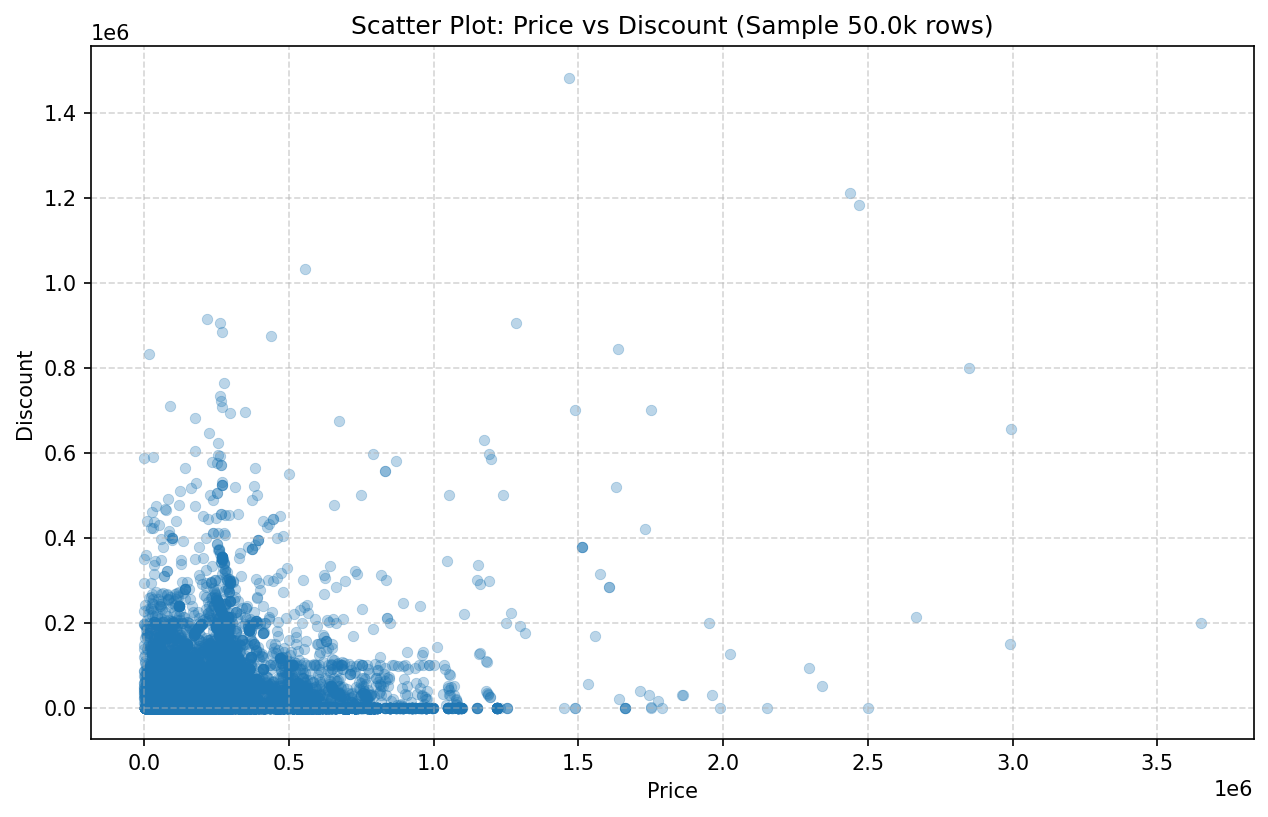

In [48]:
from IPython.display import Image, display

# Đường dẫn file bạn vừa lưu
img_path = 'visualize/transaction/scatter_price_discount.png'

print("Kết quả biểu đồ:")
display(Image(filename=img_path))

In [50]:
csv_dir = "statistics/transaction/item_behavior"
img_dir = "visualize/transaction/item_behavior"

os.makedirs(csv_dir, exist_ok=True)
os.makedirs(img_dir, exist_ok=True)

In [52]:
# item popularity vs average discount

# Collect data
df = trans

print("=== Item Popularity vs Average Discount ===")

# 1. Tính popularity per item
item_pop = df.group_by("item_id").agg([
    pl.count().alias("tx_count"),
    pl.col("discount").mean().alias("avg_discount")
])

# 2. Lưu CSV
csv_path = f"{csv_dir}/item_popularity_vs_avg_discount.csv"
item_pop.write_csv(csv_path)
print("✓ Saved CSV:", csv_path)

# 3. Vẽ biểu đồ scatter
plt.figure(figsize=(8,6))
plt.scatter(item_pop["tx_count"], item_pop["avg_discount"], s=8, alpha=0.4)
plt.xlabel("Item Popularity (Transactions)")
plt.ylabel("Average Discount")
plt.title("Item Popularity vs Average Discount")

img_path = f"{img_dir}/item_popularity_vs_avg_discount.png"
plt.savefig(img_path, dpi=300, bbox_inches="tight")
plt.close()

print("✓ Saved PNG:", img_path)

=== Item Popularity vs Average Discount ===


C:\Users\tncn2\AppData\Local\Temp\ipykernel_14744\4114699788.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("tx_count"),


✓ Saved CSV: statistics/transaction/item_behavior/item_popularity_vs_avg_discount.csv
✓ Saved PNG: visualize/transaction/item_behavior/item_popularity_vs_avg_discount.png


# EDA khi join với bảng item

In [7]:
trans_item = trans.join(
    item.select(["item_id", "category_l1"]),
    on="item_id",
    how="left"
)

In [8]:
cols_to_drop = [
    "timestamp",
    "event_type",
    "event_value",
    "date_key",
    "user_id",
    "updated_date",
    "is_deleted",
]

df = trans_item.drop(cols_to_drop)
df.head()

item_id,price,quantity,customer_id,created_date,channel,payment,location,discount,category_l1
str,"decimal[38,4]",i32,i32,datetime[μs],str,str,i32,"decimal[38,4]",str
"""7115000000004""",49000.0000,1,5254214,2024-12-24 18:17:01.027,"""In-Store""","""VietQR""",656,0.0000,"""Thực phẩm cho bé"""
"""0029130000030""",69000.0000,1,7573232,2024-12-24 19:28:01.870,"""In-Store""","""Tiền mặt""",143,0.0000,"""Thực phẩm cho bé"""
"""3496000000053""",75000.0000,2,8187418,2024-12-24 19:50:43.760,"""In-Store""","""MoMo""",213,0.0000,"""Thời trang"""
"""2700000000002""",58500.0000,2,8187418,2024-12-24 19:49:39.223,"""In-Store""","""MoMo""",213,13000.0000,"""Vệ sinh"""
"""0029110000036""",89000.0000,1,6931560,2024-12-28 09:49:33.780,"""Android""","""MoMo""",590,10000.0000,"""Thực phẩm cho bé"""


In [9]:
df = df.with_columns([
    pl.col("created_date").dt.date().alias("created_date")
])

In [15]:
category_l1_count = (
    df.group_by("category_l1")
      .agg(pl.count().alias("n_transactions"))
      .sort("n_transactions", descending=True)
)

C:\Users\tncn2\AppData\Local\Temp\ipykernel_6588\1961061121.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("n_transactions"))


In [16]:
import os
os.makedirs("statistic", exist_ok=True)

output_path = "statistic/category_l1_count.csv"
category_l1_count.write_csv(output_path)

print("Đã lưu:", output_path)

Đã lưu: statistic/category_l1_count.csv


In [18]:
trans_brand = trans.select(["item_id"]).join(
    item.select(["item_id", "category_l1", "brand"]),
    on="item_id",
    how="left"
)

In [19]:
brand_count = (
    trans_brand
        .group_by("brand")
        .agg(pl.count().alias("n_transactions"))
        .sort("n_transactions", descending=True)
)

C:\Users\tncn2\AppData\Local\Temp\ipykernel_6588\2796015435.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("n_transactions"))


In [20]:
pl.Config.set_tbl_rows(None)
pl.Config.set_tbl_cols(None)

print(brand_count)


shape: (885, 2)
┌─────────────────┬────────────────┐
│ brand           ┆ n_transactions │
│ ---             ┆ ---            │
│ str             ┆ u32            │
╞═════════════════╪════════════════╡
│ Animo           ┆ 3907618        │
│ HOFF            ┆ 1145820        │
│ Takato          ┆ 825889         │
│ Không xác định  ┆ 751580         │
│ Cây Thị         ┆ 647871         │
│ …               ┆ …              │
│ Oral-B          ┆ 1              │
│ Canpol (Ba Lan) ┆ 1              │
│ PRESSED PURITY  ┆ 1              │
│ GB              ┆ 1              │
│ NamYang         ┆ 1              │
└─────────────────┴────────────────┘


In [ ]:
import os
os.makedirs("statistic", exist_ok=True)

output_path = "statistics/transaction/brand_transaction_count.csv"
brand_count.write_csv(output_path)

print("Đã lưu CSV vào:", output_path)

Đã lưu CSV vào: statistics/transaction/brand_transaction_count.csv
